# Case study: Periodograms of Keplerian signals

Often the first step in identifying a companion to a star from time series data is to find or test trial orbital periods by computing a periodogram of the data. A periodogram is a measure of the "power" of a signal as a function of frequency or period. For irregularly spaced data (nearly always the case), a common periodogram choice is the [Lomb-Scargle periodogram](https://docs.astropy.org/en/stable/timeseries/lombscargle.html), which computes the log-likelihood of a sinusoidal model fitted to the data on a grid of trial frequencies. This approach is fast because the model is linear in the other parameters (amplitudes of sin and cos terms), and the log-likelihood can be computed analytically (typically taken to be the maximum log-likelihood over the linear parameters). For eccentric orbits, the signal is not sinusoidal, but multi-term or multi-harmonic periodograms can improve their performance.

An alternative approach to handling eccentric or more general orbital signals is to use a "Keplerian periodogram" (e.g., [Baluev 2014](https://arxiv.org/abs/1409.6115)) or another nonlinear periodogram. These approaches can be more correct but are often slower than Lomb–Scargle because the models are nonlinear in the parameters. 

`harv` contains functionality for computing linear, Lomb–Scargle-like periodograms of any of the data types supported by the package (radial velocity, Gaia astrometry, etc.). In addition to the classic L-S approach, which maximizes the log-likelihood of the linear parameters at every trial period, we also provide a periodogram that instead marginalizes over the amplitude terms under a prior. If the prior is chosen to be Gaussian, then the marginalization can be done analytically, and the log-likelihood can be computed almost as efficiently as in the Lomb-Scargle case. This has two advantages to Lomb-Scargle: (1) the periodogram power is a marginal log-likelihood rather than a maximum log-likelihood, which can be more robust to overfitting (as we explain later), and (2) the prior can be chosen to build in physical assumptions about the systems you are searching for. For example, the prior can be made a function of the orbital period so that the amplitudes of the harmonics are expected to be smaller for longer orbital periods, as we expect from Kepler's third law (at constant masses).

We demonstrate these concepts here and compare to more classical periodograms below. 

Let's start with the imports we'll need:

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import quaxed.numpy as jnp
from astropy.table import QTable
from unxt import Q, ustrip

import harv.data as hd
import harv.models as hm
import harv.periodogram as hp
from harv.simulate import simulate_rv_sb1_data

## The Lomb–Scargle case: Maximum likelihood with a single harmonic

We'll start by computing a single-term Lomb–Scargle periodogram of a simulated radial-velocity dataset. 

This periodogram fits a sinusoidal model 

$$
y(t) = a \, \cos(2\pi\nu \, t) + b \, \sin(2\pi\nu \, t) + c
$$

to the data at each trial frequency $\nu = 1/P$ (for period $P$), where $a$ and $b$ are the amplitudes of the cosine and sine terms, and $c$ is a constant offset. The model is linear in the parameters $\boldsymbol{\theta} = (a, b, c)$, so we can solve for the best-fit parameters analytically using a least squares solve. The periodogram then reports the improvement (delta log-likelihood) of the best-fit model compared to a constant-only model at the optimized parameters. 

Here we'll simulate radial velocity data for an eccentric orbit and compute this periodogram:

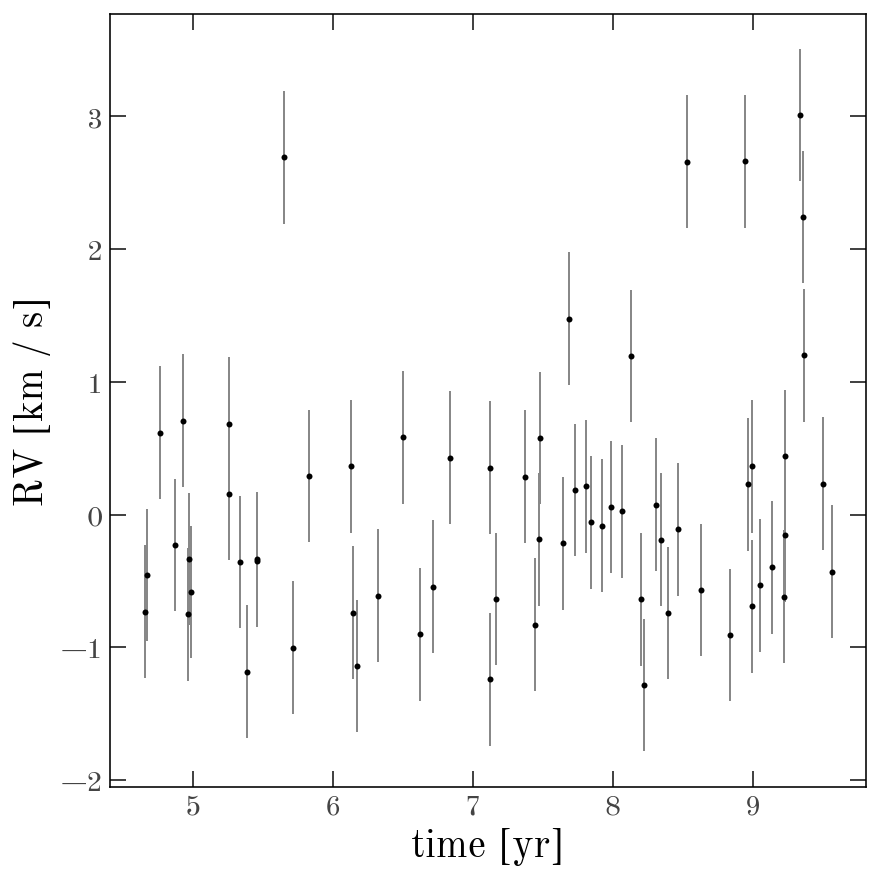

In [31]:
rv_params = {
    "period": Q(150.0, "day"),
    "eccentricity": 0.75,
    "rv_semiamp": Q(2.0, "km/s"),
    "rv_err": Q(0.5, "km/s"),
    "v_sys": Q(0.0, "km/s"),
}
data_1, truth = simulate_rv_sb1_data(seed=42, n_obs=64, **rv_params)

fig, ax = plt.subplots(figsize=(6, 6))
_ = data_1.plot(ax=ax)

To compute the periodogram, we first need to define a grid of trial periods. We can do this in `harv` using the {py:func}`harv.periodogram.frequency_grid` function in `harv.periodogram`. We'll choose a range of periods from 10 to $10^3$ days and sample 16 points per peak in the periodogram. To compute the profile likelihood periodogram (i.e., the maximum likelihood or Lomb–Scargle periodogram), we call the {py:func}`harv.periodogram.periodogram` function with `prior=False`:

In [32]:
P_min, P_max = Q([10.0, 1e3], "day")
grid = hp.frequency_grid(
    data_1, period_min=P_min, period_max=P_max, samples_per_peak=16
)
profile_pgram_nterms1 = hp.periodogram(data_1, grid, prior=False, n_terms=1)

Now we visualize the periodogram. We plot the periodogram power as a function of period using a logarithmic scale for the period axis. The top panel shows the periodogram power (a delta log-likelihood) and the lower panel shows the exponentiated power (a likelihood ratio, normalized to the maximum). 

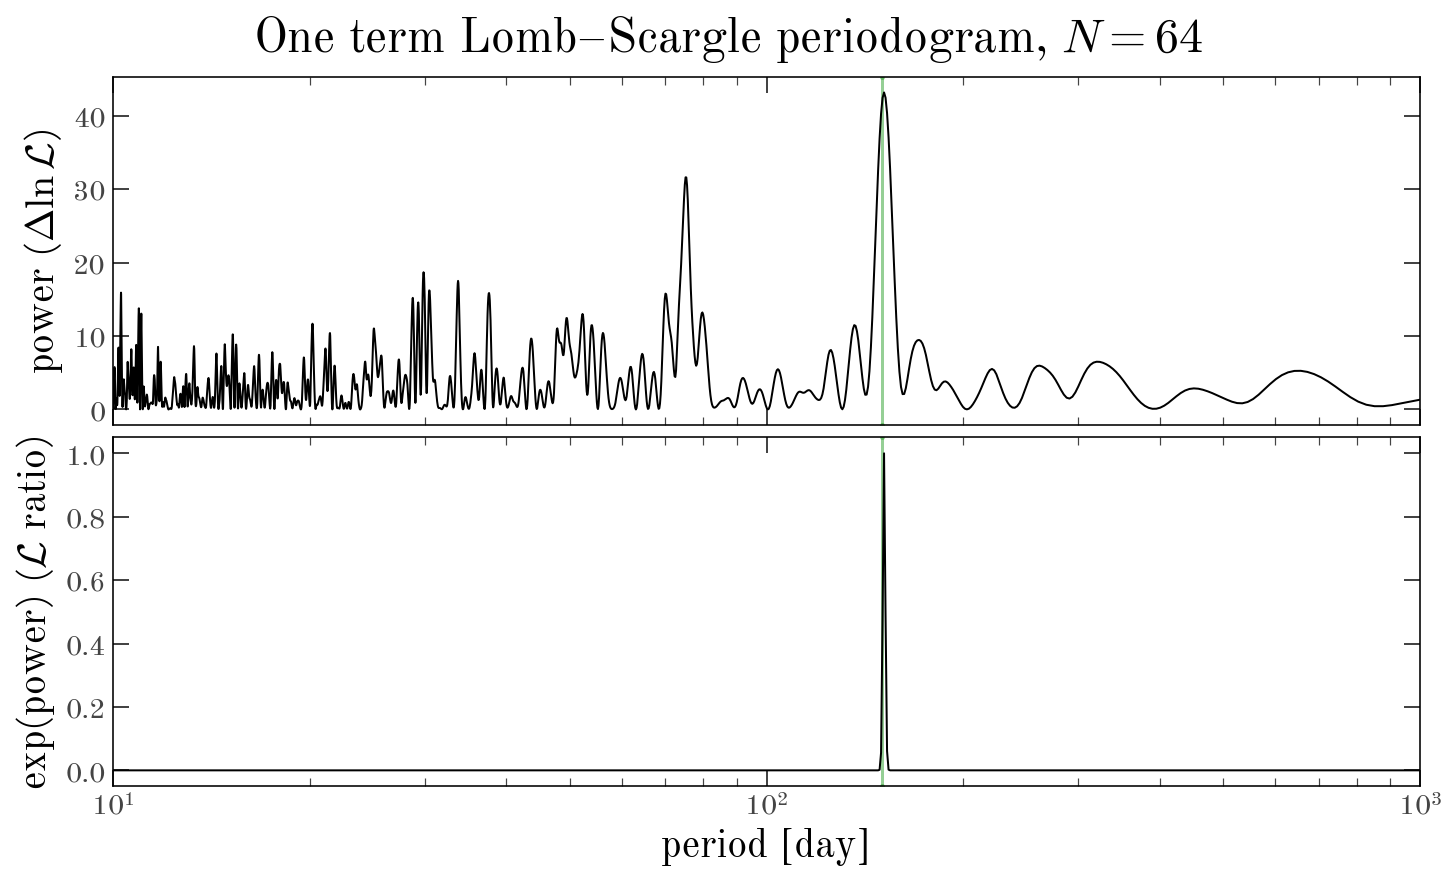

In [33]:
def plot_periodogram(pgram):
    fig, axes = plt.subplots(
        2, 1, figsize=(10, 6), sharex=True, constrained_layout=True
    )

    pgram_P = ustrip("day", pgram.period)

    ax = axes[0]
    ax.plot(
        pgram_P,
        pgram.delta_ln_likelihood,
        marker="",
        lw=1.0,
    )
    _ = ax.set(
        xscale="log",
        # xlabel="period [day]",
        ylabel=r"power ($\Delta \ln \mathcal{L}$)",
    )

    ax = axes[1]
    ax.plot(
        ustrip("day", pgram.period),
        jnp.exp(pgram.delta_ln_likelihood - pgram.delta_ln_likelihood.max()),
        marker="",
        lw=1.0,
    )
    _ = ax.set(
        xscale="log",
        xlabel="period [day]",
        ylabel=r"exp(power) ($\mathcal{L}$ ratio)",
        xlim=(jnp.min(pgram_P), jnp.max(pgram_P)),
    )

    for ax in axes:
        ax.axvline(
            ustrip("day", truth["period"]),
            color="tab:green",
            ls="-",
            alpha=0.5,
            zorder=-10,
        )

    return fig, axes


fig, _ = plot_periodogram(profile_pgram_nterms1)
_ = fig.suptitle(
    f"One term Lomb–Scargle periodogram, $N={data_1.n_times}$", fontsize=24
)

From the periodogram above, we can see that there is a clear mode at the true period of the simulated data, so that's good! It's a relatively strong signal (signal-to-noise S/N ~ 32), so that is expected.

Let's see what the data look like phases-folded at the periodogram peak:

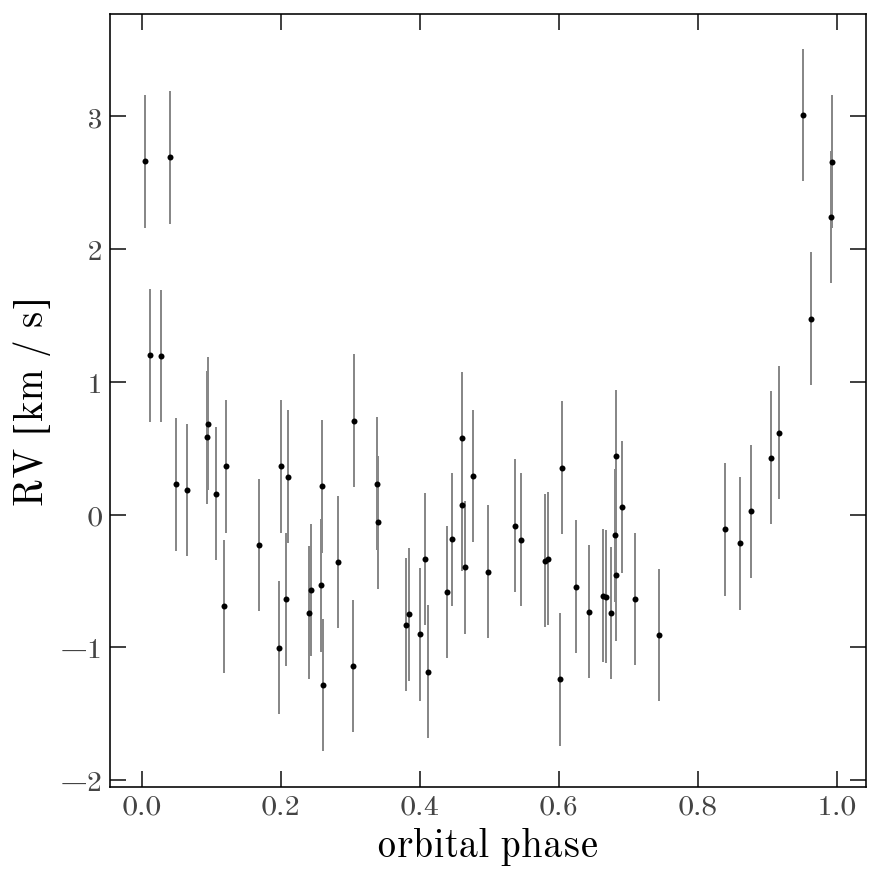

In [61]:
_ = data_1.plot(phase_fold=profile_pgram_nterms1.max_period())

That looks like a reasonable folded signal!

For this system, we know it is eccentric, so we can also see if including more harmonics in the model helps or refines the period. The extra harmonics / terms are often used to capture the eccentricity (still computing a classic Lomb–Scargle / maximum likelihood periodogram). We can do this by setting `n_terms > 1` in the {py:func}`harv.periodogram.periodogram` function. Here we compute a two-term periodogram `n_terms=2`:

In [67]:
profile_pgram_nterms2 = hp.periodogram(data_1, grid, prior=False, n_terms=2)

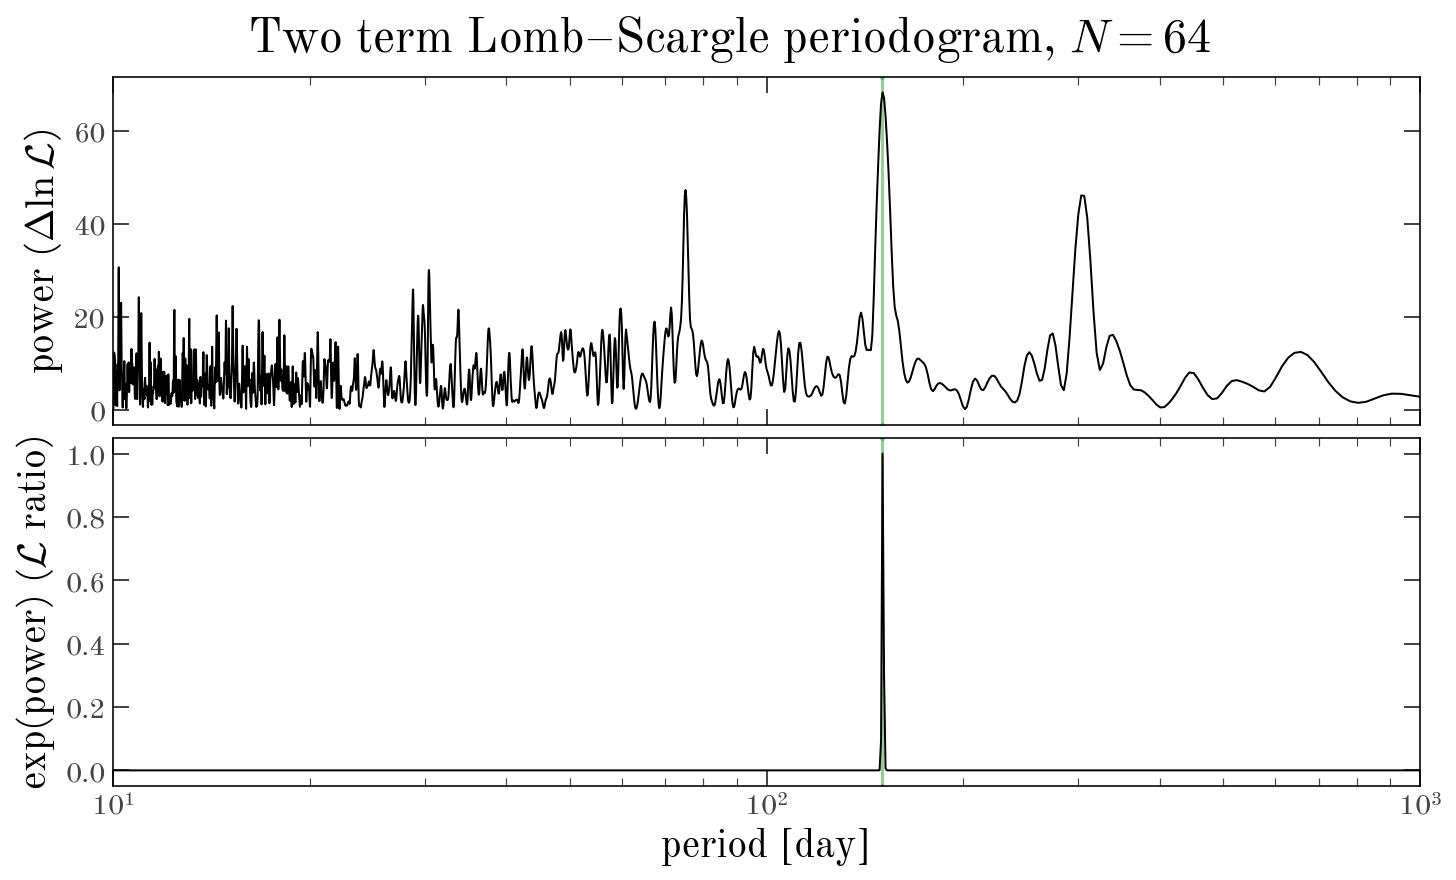

In [68]:
fig, _ = plot_periodogram(profile_pgram_nterms2)
_ = fig.suptitle(
    f"Two term Lomb–Scargle periodogram, $N={data_1.n_times}$", fontsize=24
)

In this case, adding more terms does not really help because the signal is strong and the phase coverage of the data is good. If you look at the periodogram power, the peak does get larger with the `n_terms=2` case, but it is a clear dominant mode in either case. 

What if we had less data? Let's try simulating a dataset with only 16 epochs but the same parameters:

In [36]:
data_2, truth = simulate_rv_sb1_data(seed=42, n_obs=16, **rv_params)

We now compute multi-term periodograms of this smaller dataset:

In [77]:
profile_pgrams_2 = {}
for n_terms in [1, 2, 3]:
    profile_pgrams_2[n_terms] = hp.periodogram(
        data_2, grid, prior=False, n_terms=n_terms
    )

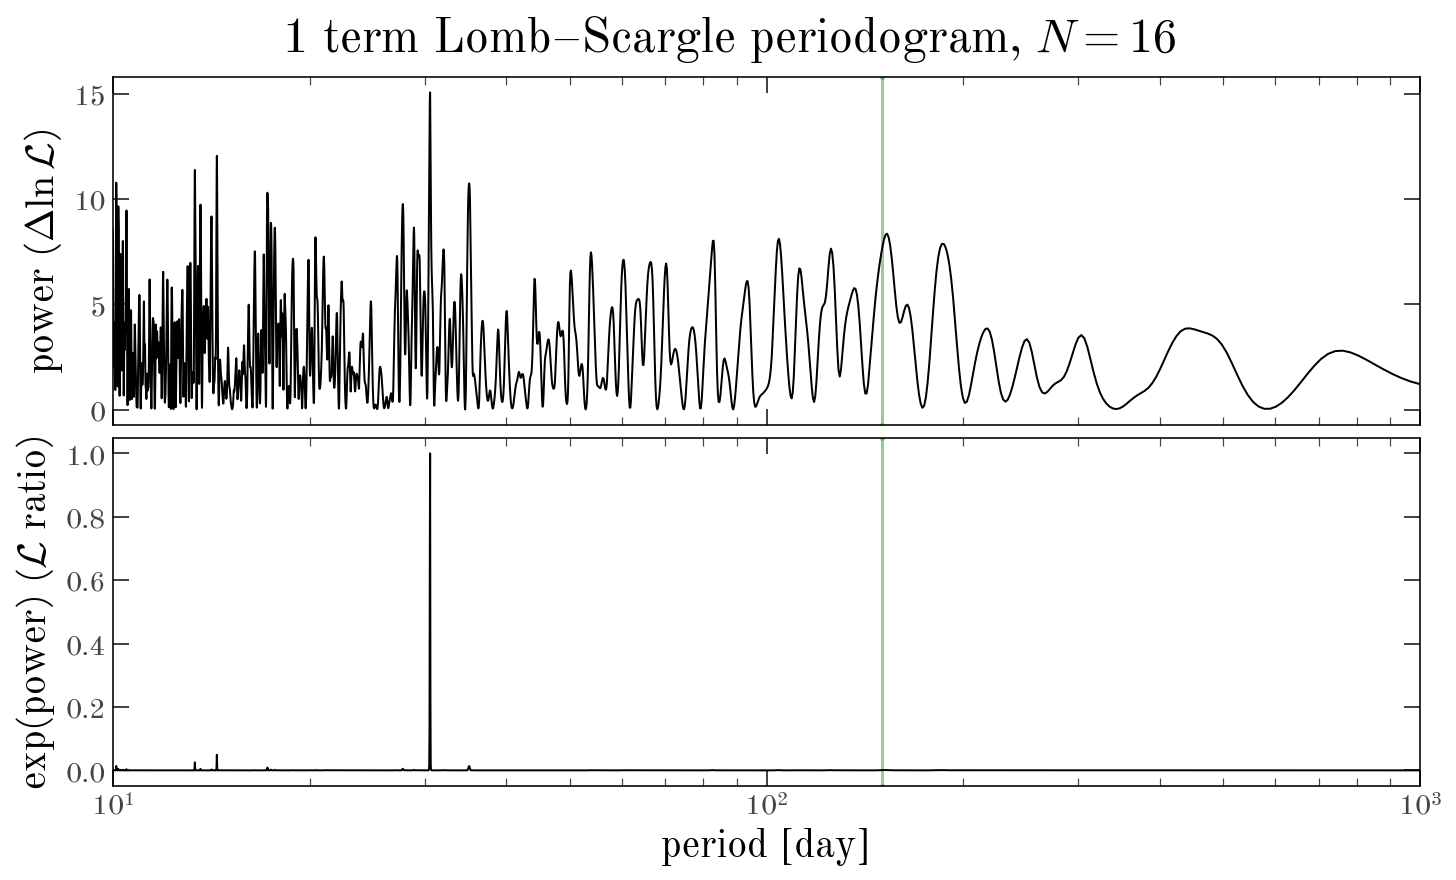

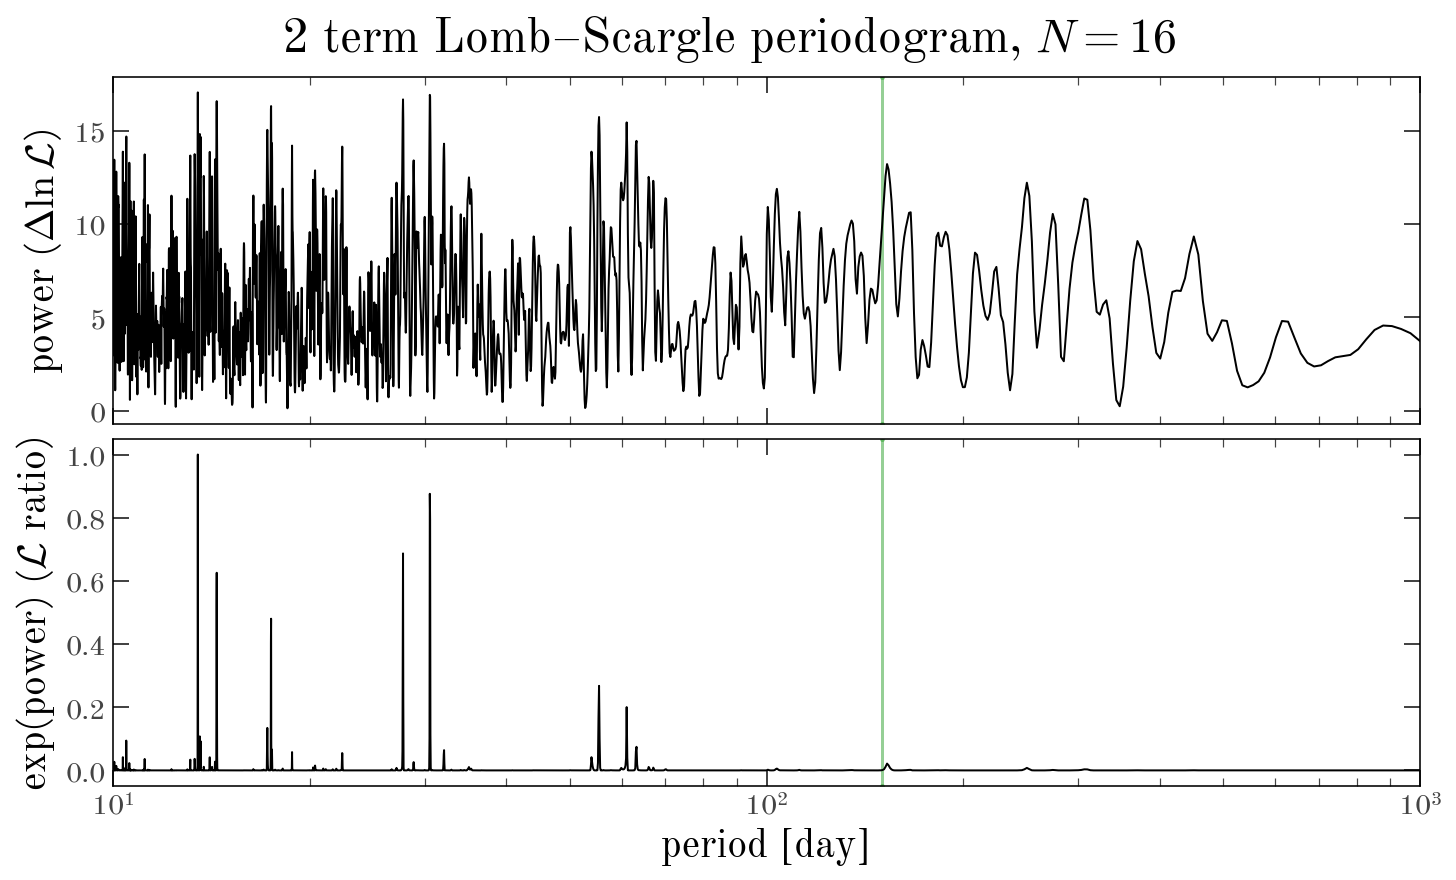

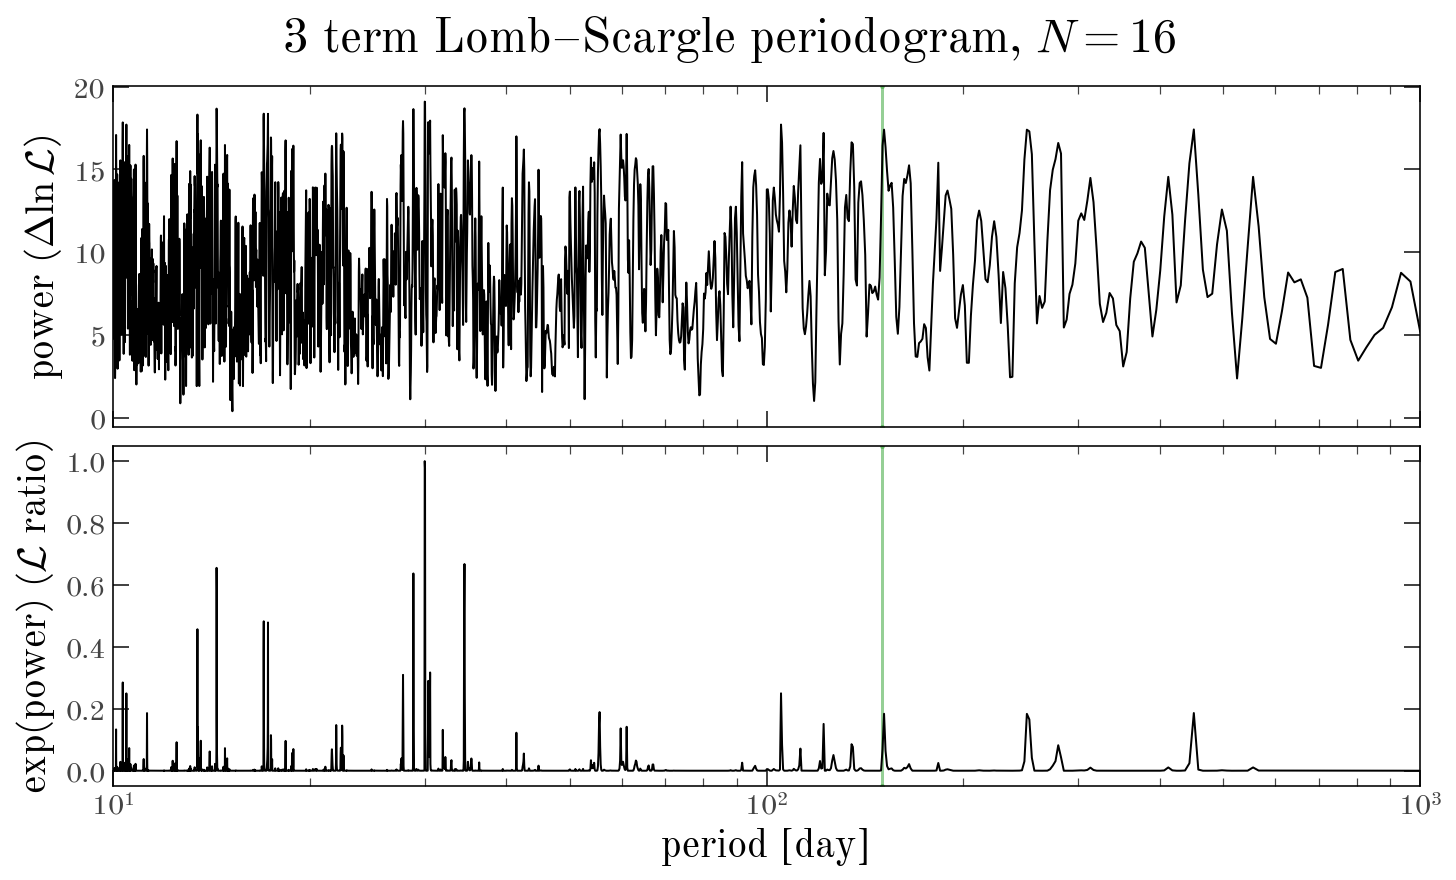

In [78]:
for n_terms, profile_pgram in profile_pgrams_2.items():
    fig, _ = plot_periodogram(profile_pgram)
    _ = fig.suptitle(
        f"{n_terms} term Lomb–Scargle periodogram, $N={data_2.n_times}$", fontsize=24
    )

With fewer epochs, none of these periodograms are conclusive. All of the periodograms show a peak near the true period, but there are many other peaks with similar or higher power. However, as we increase the number of terms, the amplitude of the mode near the true period increases relative to the other modes, even though it is still not the dominant mode. 

Another approach, which we use by default in `harv`, is to instead marginalize over the amplitudes instead of maximizing. Before we get into the math behind this approach, let's first recap the math behind Lomb–Scargle or profile periodograms, and what we can interpret from the different cases.

## The Lomb-Scargle case: Mathematical recap

TODO: Should we call these things Lomb-Scargle or just "profile" periodograms?

_This recap assumes some familiarity with the math behind Lomb–Scargle periodograms — we recommend [this review article](https://arxiv.org/abs/1703.09824) (especially Section 5 and beyond) for a good overview._

We assume we have a dataset of $N$ observations $\{y_n\}$ at times $\{t_n\}$ with uncorrelated uncertainties $\{ \sigma_n \}$, which we can pack into the diagonal of an $N \times N$ noise covariance matrix $C$. We want to compute a periodogram of this data and account for the heteroscedastic uncertainties of the data.
Periodograms are generally computed on a grid of periods or frequencies, so at a given element of the grid, we have a trial frequency $\nu$. In the case of a Lomb–Scargle periodogram, we want to fit a sinusoidal model to the data at each trial frequency - a model that looks like

$$
y(t) = a \, \cos(2\pi\nu \, t) + b \, \sin(2\pi\nu \, t) + c
$$

as defined above, where $\boldsymbol{\theta} = (a, b, c)$ are the (linear) parameters of the model. We define $X(\nu)$ to be the design matrix at a trial frequency so that

$$
X(\nu) = \begin{bmatrix}
\cos(2\pi\nu \, t_1) & \sin(2\pi\nu \, t_1) & 1 \\
\cos(2\pi\nu \, t_2) & \sin(2\pi\nu \, t_2) & 1 \\
\vdots & \vdots & \vdots \\
\cos(2\pi\nu \, t_N) & \sin(2\pi\nu \, t_N) & 1
\end{bmatrix} \quad,
$$

so the columns are the cosine and sine terms of each harmonic, plus a column of ones for the constant term. 
With these definitions, the parameters $\boldsymbol{\theta}$ that maximize the likelihood at a given trial frequency are given by the usual least-squares solution

$$
\hat{\theta}(\nu) = \left(X^\top C^{-1} X\right)^{-1} X^\top C^{-1} y \quad .
$$

In the case of the Lomb–Scargle periodogram, the periodogram power is typically defined as the _improvement_ in this model fit over a base model. 
If the base model is a constant-only model, then the base design matrix is just a column of ones, and the base model parameter is just the inverse-variance-weighted mean of the data, $\hat{y} = \sum_i w_i y_i / \sum_i w_i$ where $w_i = 1/\sigma_i^2$.
The periodogram power $z(\nu)$ is then defined as the difference in log-likelihood between the trial model and the base model, evaluated at the optimal parameters,

$$
z(\nu) = \ln \mathcal{N}\!\left(y \mid X\hat{\theta}, C\right)
    - \ln \mathcal{N}\!\left(y \mid \hat{y}, C\right)
$$

which here is identical to the difference in chi-squared between the sinusoid model and the constant model evaluated at the optimal parameters

$$z(\nu) = \tfrac{1}{2}\left[\chi^2_\mathrm{const} - \chi^2_\mathrm{sinusoid}(\nu)\right] \quad .
$$

This is equivalent to a ratio of profile likelihoods for the two models because the amplitudes have been optimized away at every trial frequency. 
Because the sinusoid model contains the base model, $z(\nu) \geq 0$ always.

TODO: introduce FAP and p-values, detection thresholds.

TODO: demonstrate FAP/p-value concepts using the periodograms we've already computed on data_1 and data_2 above (i.e. draw thresholds)

## The Bayes Factor Periodogram: Marginalizing over the amplitudes

Instead of optimizing for the parameters that maximize the likelihood at each trial period/frequency (see the Lomb-Scargle section above), we can instead put a prior on the amplitudes and integrate them out (i.e. marginalize). 
If the prior is Gaussian, the integral can be done analytically and costs about the same as the least-squares solve:

TODO: use different letter here, then define Z(\nu) to be BF periodogram??

$$
\begin{align}
Z(\nu) &= \int d\theta \,
    \mathcal{N}(y \mid X\theta, C) \, \mathcal{N}(\theta \mid 0, \Lambda) \\
&= \mathcal{N}(y \mid 0,\ C + X \Lambda X^\top) \quad .
\end{align}
$$

To turn this into a periodogram analogous to Lomb-Scargle / profile periodogram above, we can compute the marginal likelihood at each trial frequency under the sinusoid model and compare it to the marginal likelihood of a constant model (or other base model). The periodogram power is $\Delta(\nu) = \ln Z(\nu) - \ln Z_\mathrm{base}$. 
In this version of a periodogram, So $\Delta$ (the periodogram power) is a log-Bayes factor for "constant + orbit harmonics" versus "constant" model at each trial frequency, rather than a maximum log-likelihood ratio. 

The difference is that the marginal likelihood contains an Occam penalty, which acts as a penalty for the number of free parameters in the model. So adding a harmonic only increases $\Delta$ if it improves the fit by more than that factor.
Here we define the Occam term more concretely.
If $\Lambda$ is the prior covariance of the amplitudes $\theta$ (typically diagonal), and define

$$A(\nu) = X^\top C^{-1} X \quad , \qquad b(\nu) = X^\top C^{-1} y \quad ,$$

so that $A$ is the Fisher information matrix of the amplitudes and $b$ is the data
projected onto the model columns. 
With these definitions, the (log) marginal likelihood above expands to

$$\ln Z(\nu) = -\tfrac{1}{2} y^\top C^{-1} y
    + \tfrac{1}{2} b^\top \left(A + \Lambda^{-1}\right)^{-1} b
    - \underbrace{\tfrac{1}{2} \ln \det\!\left(I + \Lambda A\right)}_{O(\nu)}
    + \mathrm{const.} \quad ,$$

where the constant depends only on the data and cancels in $\Delta$. The first two terms measure how well the model fits, and the third is the "Occam factor" or Occam term,

$$O(\nu) = \tfrac{1}{2} \ln \det\!\left(I + \Lambda \, X^\top C^{-1} X\right) \quad .$$

$O(\nu)$ compares the width of the prior on each amplitude to how tightly the data constrain that amplitude. 
For a single amplitude with prior width $\sigma$ that the data constrain with Fisher information $\lambda$, it contributes $\tfrac{1}{2}\ln(1 + \sigma^2\lambda)$, which is close to zero when the prior is narrower than the data can resolve and grows like $\ln \sigma$ if the data constrain the amplitude well. 
Summed over columns, a well-constrained model takes on roughly $\ln\sigma$ per amplitude column, so $\Delta \approx z - \Delta O$ where $\Delta O$ is the difference in Occam term between the trial and base models. 
This is effectively a penalty for adding more parameters to the model.
And by the way: this is very related to the "Bayesian Information Criterion" (BIC) often used for model selection, which is a large-data approximation to the Occam term (where the data is large enough that the prior scales don't matter, which is why the BIC does not require defining a prior).

So how do we choose the prior on the linear amplitudes?

In `harv`, the amplitude prior is required and must be specified explicitly (i.e. the periodogram does not use the data to set the prior scale). The simplest form of the prior would be period-independent widths `sigma_amp` on the harmonic amplitudes and `sigma_v0` on the systemic velocity.

Let's compare the marginal and profile (Lomb–Scargle) periodograms on the same data and the same period grid. We'll use a well-sampled dataset (32 epochs) here, so we can see what marginalization does in a regime where both periodograms work, and we'll come back to the case of sparse data afterwards:

TODO: label on marginal periodogram should be "bayes factor" or something else

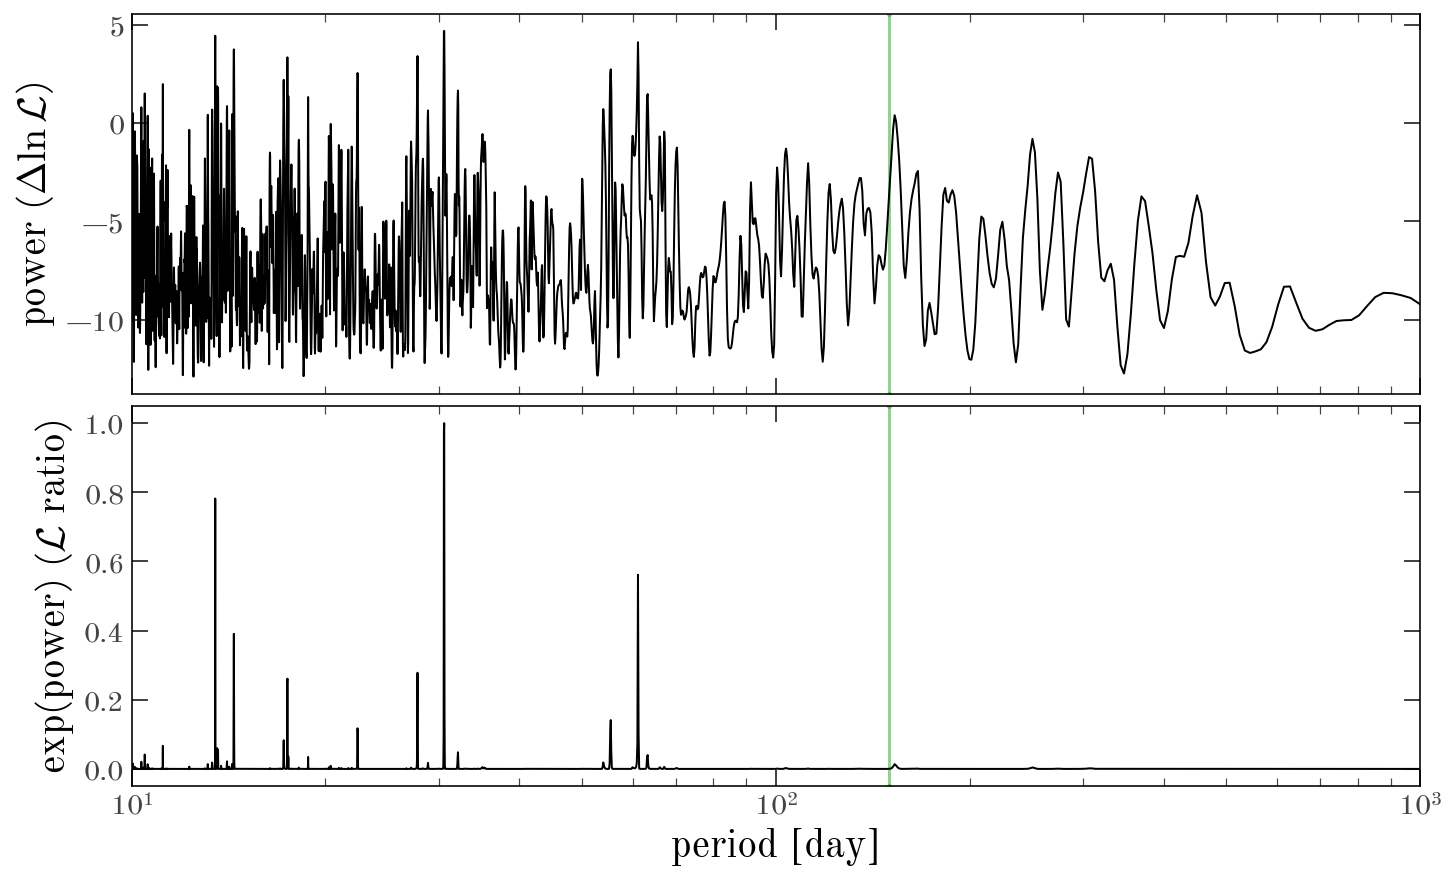

In [43]:
fourier_prior = hm.FourierRV(n_terms=2).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_amp=Q(5.0, "km/s"),
    sigma_v0=Q(100.0, "km/s"),
)
marginal_const_amp = hp.periodogram(data_2, grid, prior=fourier_prior, n_terms=2)

fig, _ = plot_periodogram(marginal_const_amp)

TODO: prior-dependence of bayes factor

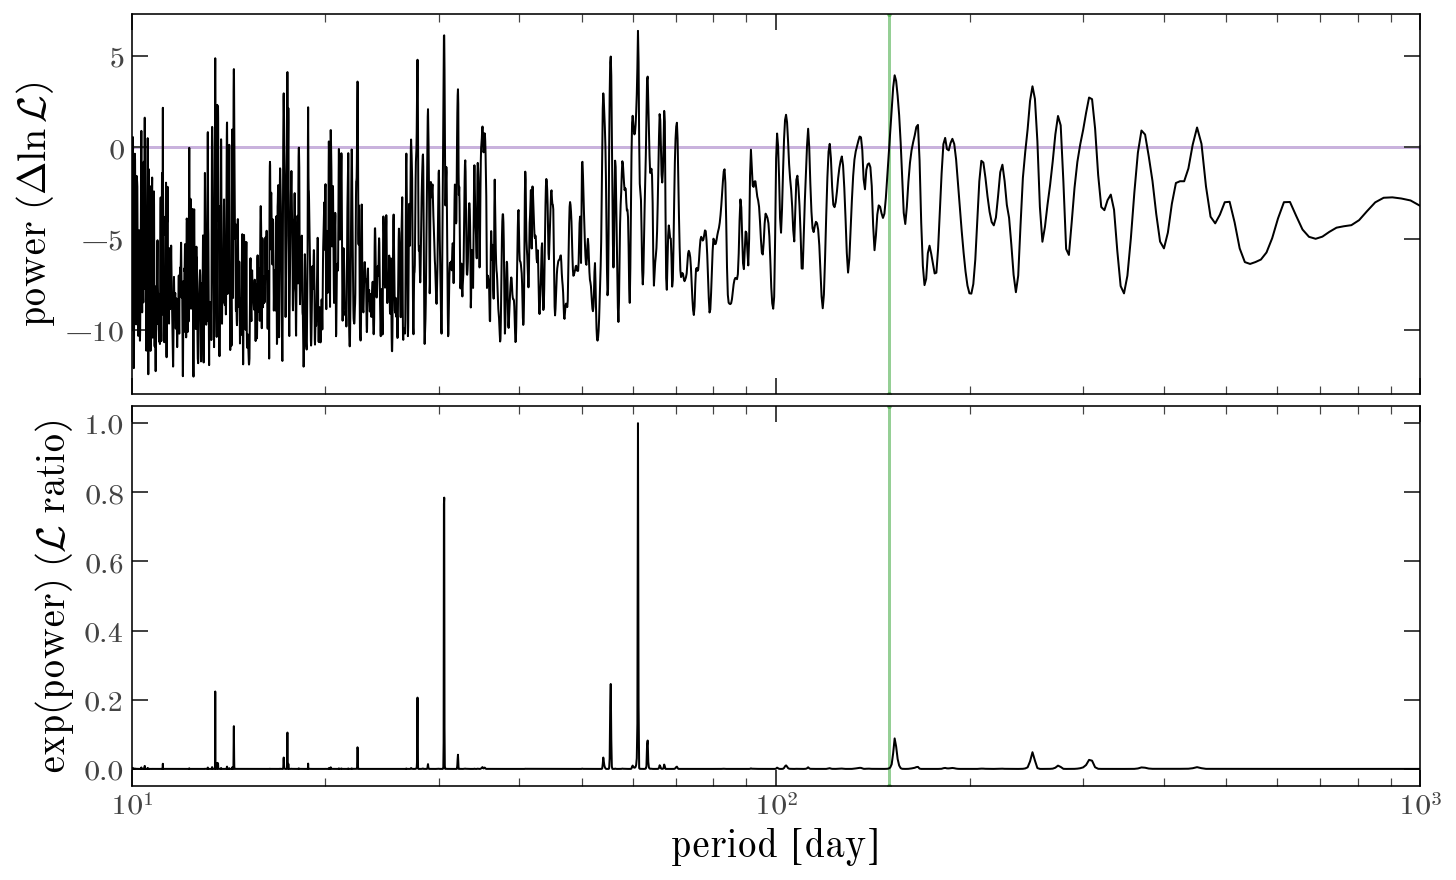

In [58]:
fourier_prior_P_dep = hm.FourierRV(n_terms=2).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_K0=rv_params["rv_semiamp"],
    P0=rv_params["period"],
    sigma_v0=Q(100.0, "km/s"),
)
marginal_P_dep_amp = hp.periodogram(data_2, grid, prior=fourier_prior_P_dep, n_terms=2)

fig, _ = plot_periodogram(marginal_P_dep_amp)
fig.axes[0].axhline(0.0, color="tab:purple", ls="-", alpha=0.5, zorder=-10)

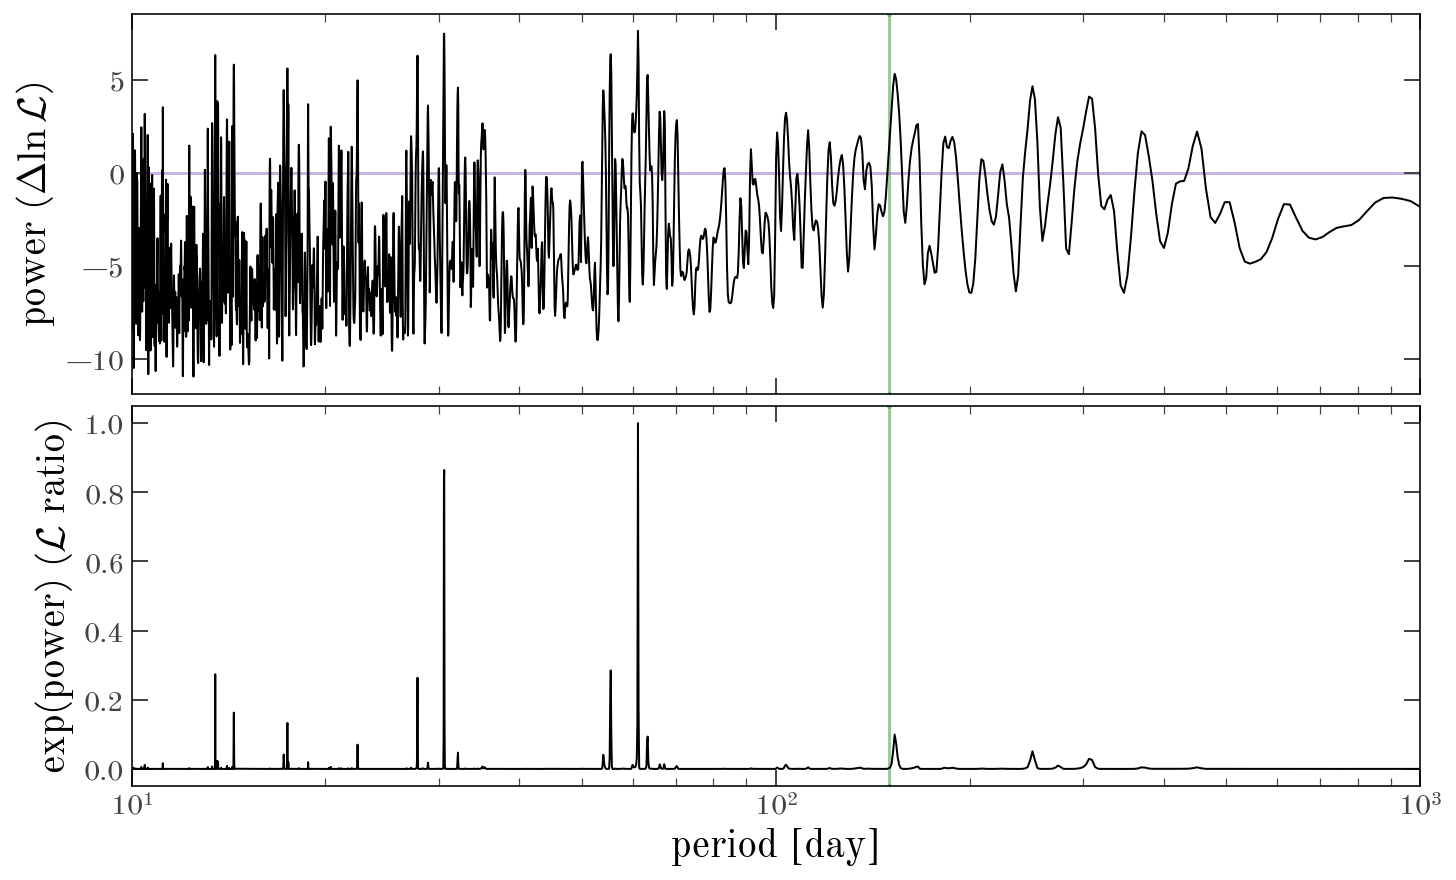

In [59]:
fourier_prior_P_dep = hm.FourierRV(n_terms=2).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_K0=Q(1.0, "km/s"),
    P0=Q(1.0, "year"),
    sigma_v0=Q(100.0, "km/s"),
)
marginal_P_dep_amp = hp.periodogram(data_2, grid, prior=fourier_prior_P_dep, n_terms=2)

fig, _ = plot_periodogram(marginal_P_dep_amp)
fig.axes[0].axhline(0.0, color="tab:purple", ls="-", alpha=0.5, zorder=-10)

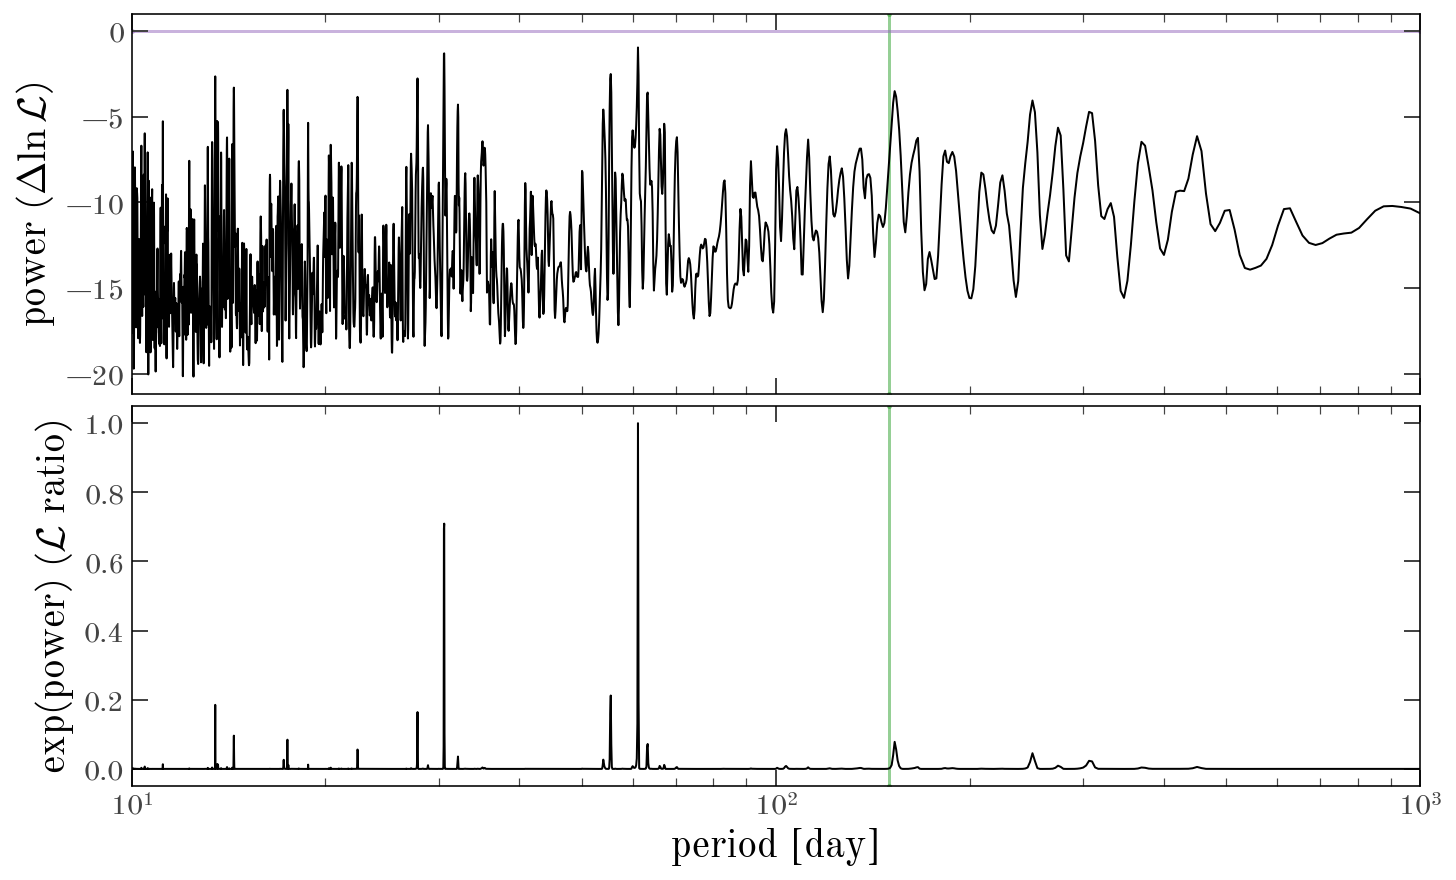

In [60]:
fourier_prior_P_dep = hm.FourierRV(n_terms=2).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_K0=Q(10.0, "km/s"),
    P0=Q(1.0, "year"),
    sigma_v0=Q(100.0, "km/s"),
)
marginal_P_dep_amp = hp.periodogram(data_2, grid, prior=fourier_prior_P_dep, n_terms=2)

fig, _ = plot_periodogram(marginal_P_dep_amp)
fig.axes[0].axhline(0.0, color="tab:purple", ls="-", alpha=0.5, zorder=-10)

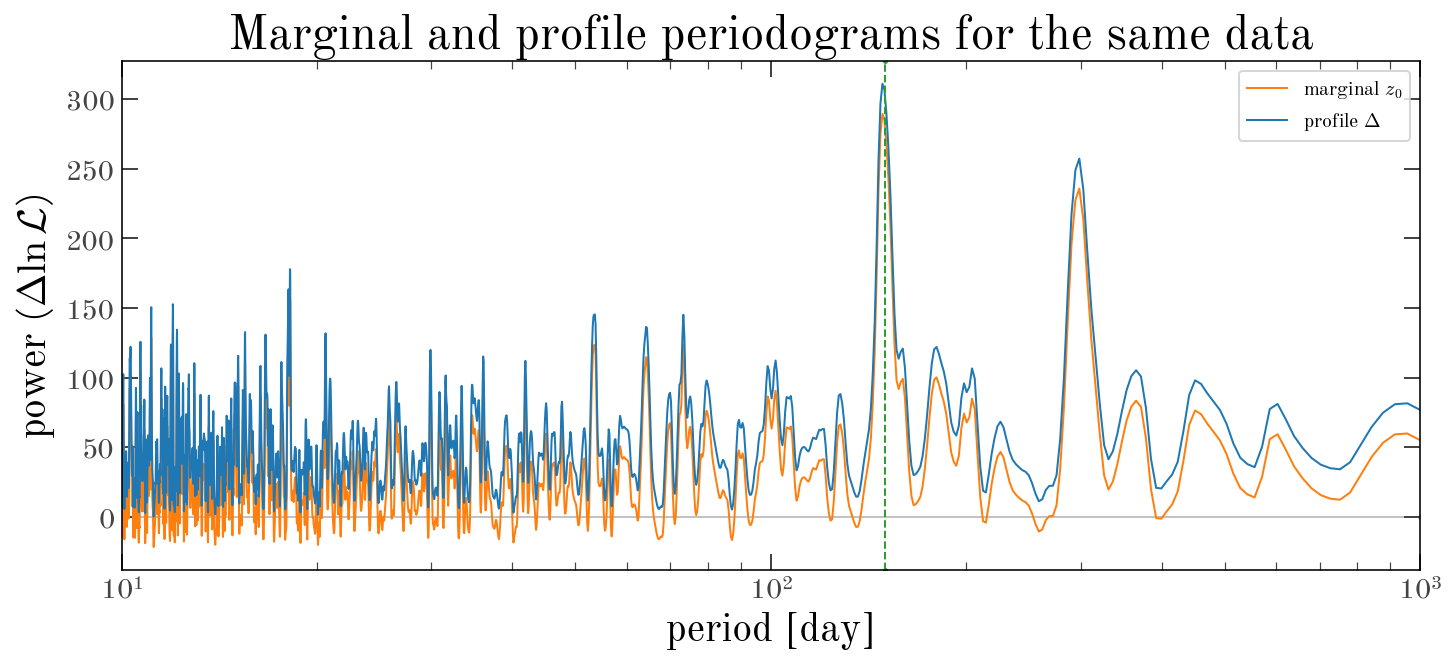

In [50]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.plot(
    ustrip("day", marginal_32.period),
    marginal_32.delta_ln_likelihood,
    color="tab:orange",
    lw=1,
    marker="",
    label=r"marginal $z_0$",
)
ax.plot(
    ustrip("day", profile_32.period),
    profile_32.delta_ln_likelihood,
    color="tab:blue",
    lw=1,
    marker="",
    label=r"profile $\Delta$",
)
ax.axhline(0.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(float(ustrip("day", truth["period"])), color="tab:green", ls="--", lw=1)
ax.set(
    xlabel="period [day]",
    ylabel=r"power ($\Delta \ln \mathcal{L}$)",
    xscale="log",
    xlim=(1e1, 1e3),
)
ax.legend()
_ = ax.set_title("Marginal and profile periodograms for the same data")

The two periodograms look very similar -- they have the same shape but are offset from one another, and the offset is nearly constant across the grid. That offset is the Occam penalty for the four harmonic amplitudes. It is nearly constant here because the prior is the same at every period and, with 32 epochs, the amplitudes are well constrained at every trial period.

There is one qualitative difference between the two periodograms: The profile periodogram is never negative, because the trial model contains the constant model and extra parameters can only lower $\chi^2$. The marginal periodogram goes negative wherever the Occam penalty exceeds the improvement in the fit -- in those cases, a trial period is disfavored relative to the constant model, which gives the marginal case slightly more interpretability than the profile case.

On well-sampled data with a period-independent prior, the two periodograms are effectively the same. However, the raw values of the marginal and the profile periodogram are not comparable. The marginal periodogram is especially useful use on sparse data, and for incorporating physical priors on the data (e.g., ones that depend on period), as we see below.

## Data with few epochs

A trial model with $H$ harmonics has $2H + 1$ linear parameters. When the number of epochs is close to or below that number, a maximum-likelihood periodogram will generally overfit the data and produce spurious peaks. Marginalizing over the amplitudes with a prior can help mitigate this issue by penalizing complex models. But generally in this regime there will be many modes in the periodogram, and it will be difficult to identify the true period with any approach.

For example, the periodogram below is for a dataset with only 10 epochs but with `n_terms=3` (so 7 linear parameters). The true period is still a local mode, but it is buried under a forest of other peaks.

TODO: this seciton doesn't really make sense unless we compare to profile, given the flow?

/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_38191/1840302385.py:18: UserWarning: n_terms=3 leaves 1.7 observations per linear column (7 columns, 12 observations), below the 2 per column this check expects. The amplitude prior keeps the marginal statistic well-posed at any column count, so n_terms is not reduced, but the periodogram is increasingly prior-driven and spurious alias peaks may dominate. Pass a smaller n_terms to silence this.
  marginal_5 = hp.periodogram(data, grid, prior=fourier_prior, n_terms=3)


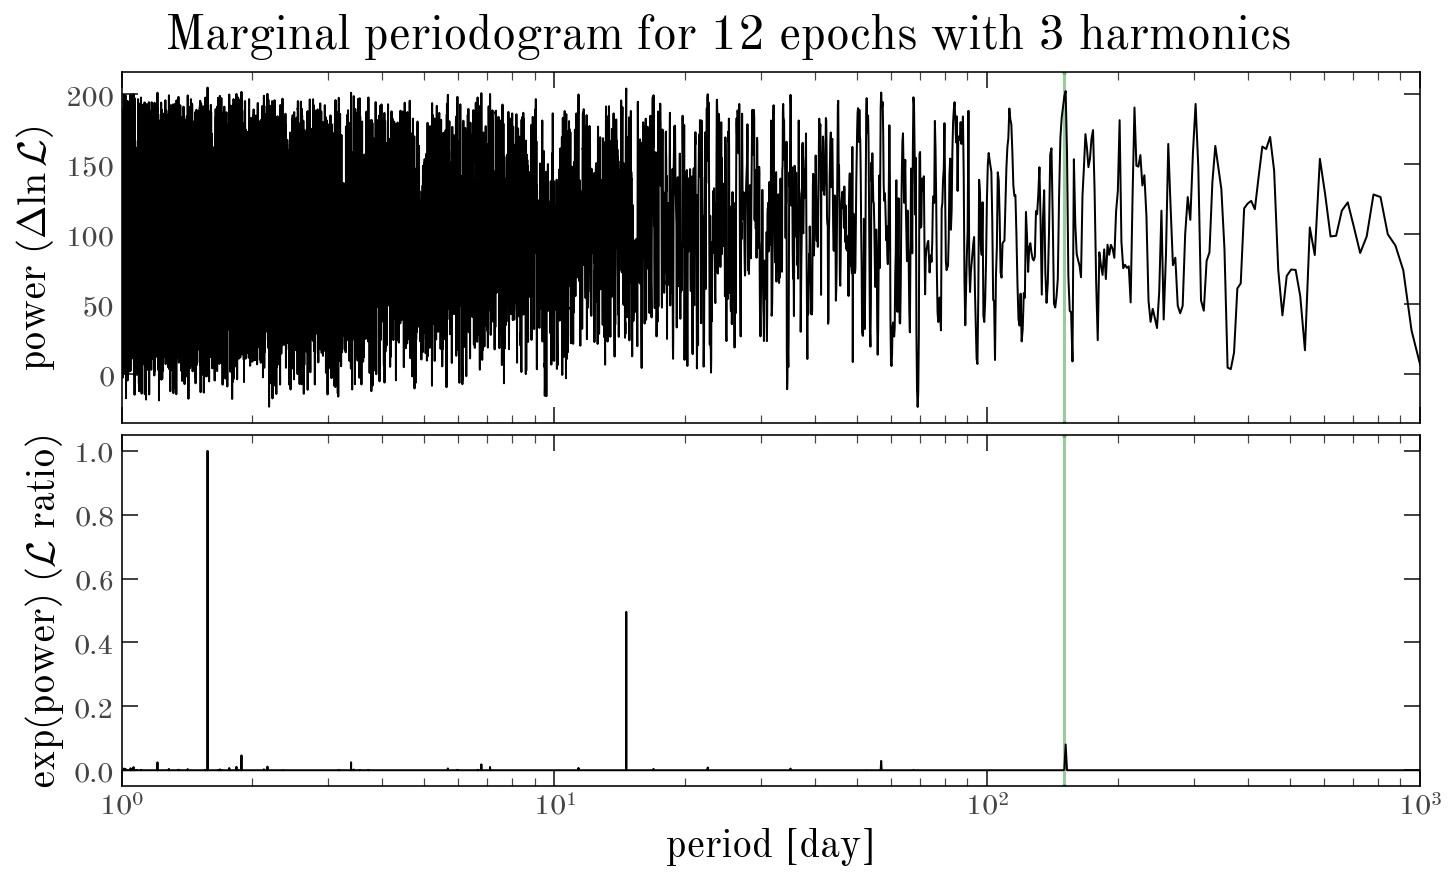

In [51]:
n_obs = 12
data, truth = simulate_rv_sb1_data(
    seed=12345,
    n_obs=n_obs,
    period=Q(150.0, "day"),
    eccentricity=0.6,
    rv_semiamp=Q(5.0, "km/s"),
    rv_err=Q(0.5, "km/s"),
    v_sys=Q(0.0, "km/s"),
)

fourier_prior = hm.FourierRV(n_terms=3).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_amp=Q(30.0, "km/s"),
    sigma_v0=Q(100.0, "km/s"),
)
marginal_5 = hp.periodogram(data, grid, prior=fourier_prior, n_terms=3)

fig, _ = plot_periodogram(marginal_5)
_ = fig.suptitle(
    f"Marginal periodogram for {n_obs} epochs with 3 harmonics", fontsize=24
)

## Period-dependent amplitude priors

So far the amplitude prior has been constant with period. In this regime, the marginal periodogram is (nearly) the profile periodogram plus a constant. But we are often searching for orbits, and orbits obey Kepler's third law. For a constant mass system, we know that the amplitude (in radial velocity amplitude or semi-major axis) should scale with period. For example, for astrometry at fixed masses, $a \propto P^{2/3}$. For radial velocity semi-amplitude, the relationship is $K \propto P^{-1/3}$.

`harv` allows the amplitude prior to be a function of period, so we can encode this knowledge into the periodogram. The figure below shows the marginal periodogram for the same 10-epoch dataset as above, but with a prior that scales with $P^{-1/3}$ for the radial velocity amplitudes. More specifically, we set the prior scale on $K$ to be $\sigma_K(P) = \sigma_{K,0} \times (P / P_0)^{-1/3}$. We can enable this in `harv` by specifying $\sigma_{K,0}$ (`sigma_K0`) and $P_0$ (`P0`) in the prior:

In [52]:
fourier_prior = hm.FourierRV(n_terms=3).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_K0=Q(10.0, "km/s"),
    P0=Q(1.0, "year"),
    sigma_v0=Q(100.0, "km/s"),
)
marginal_P_dep = hp.periodogram(data, grid, prior=fourier_prior, n_terms=3)

/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_38191/1091348521.py:8: UserWarning: n_terms=3 leaves 1.7 observations per linear column (7 columns, 12 observations), below the 2 per column this check expects. The amplitude prior keeps the marginal statistic well-posed at any column count, so n_terms is not reduced, but the periodogram is increasingly prior-driven and spurious alias peaks may dominate. Pass a smaller n_terms to silence this.
  marginal_P_dep = hp.periodogram(data, grid, prior=fourier_prior, n_terms=3)


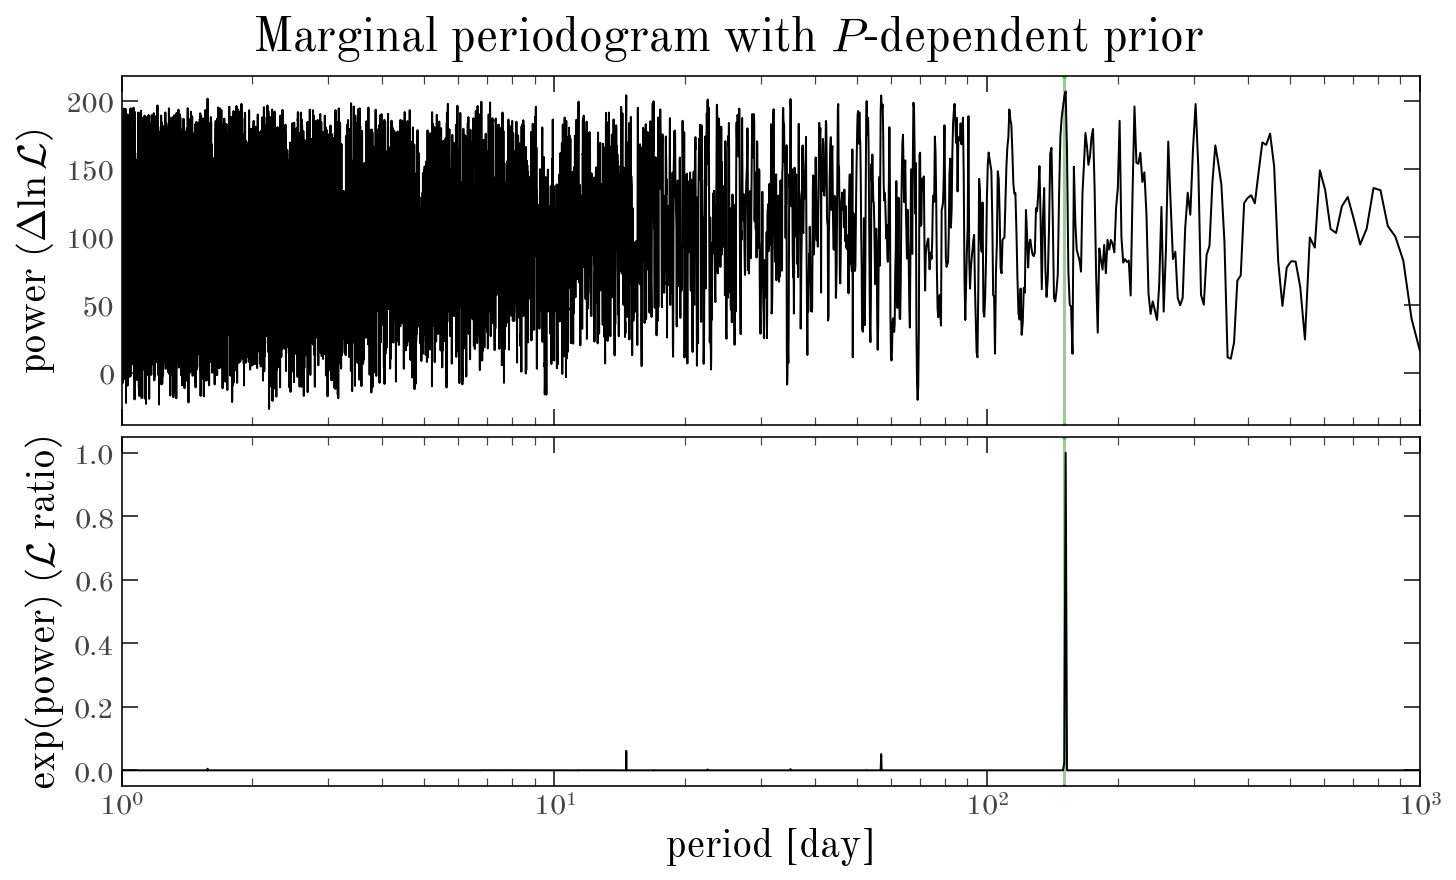

In [53]:
fig, _ = plot_periodogram(marginal_P_dep)
_ = fig.suptitle("Marginal periodogram with $P$-dependent prior", fontsize=24)

Here we see that the true mode is now the dominant mode in the periodogram. This prior effectively downweights the short period modes relative to longer period modes, which here has the effect of upweighting the true mode. This is useful feature of the marginal periodogram: it allows us to incorporate physical knowledge about the systems we are looking for into the periodogram.

### What this does to the periodogram, in more detail

A period-dependent amplitude prior enters the periodogram power through the Occam
factor discussed above. Where the amplitudes are well constrained, this term is approximately $\ln\sigma(P) + \mathrm{const.}$, so the difference in the periodogram power between the period-dependent prior and a flat prior is

$$\Delta_{P~\mathrm{dep.}}(\nu) - \Delta_\mathrm{flat}(\nu) \;\approx\; -\,N_{\mathrm{amp}}\,\beta\,\ln(P/P_0) \quad ,$$

where $N_{\mathrm{amp}}$ is the number of harmonic amplitude columns (linear parameters) in the model. For the RV case $\beta = -1/3$ and $N_{\mathrm{amp}} = 2H$, so a period-dependent prior produces a power bias of $+2H/3$ per e-fold in period. For astrometry, $\beta = +2/3$ and $N_{\mathrm{amp}} = 4H$, so the bias is $-8H/3$ per e-fold. 

One important note here is that `sigma_K0` acts as a "gain", so it controls how much of the period grid feels the period dependence. If set too large, the entire grid is biased toward long period modes, but if it is set too small, the prior is effectively flat and does not help to upweight the true mode.

This goes somewhat counter to usual advice about setting prior widths (i.e. wanting to set them wide to be uninformative). Here, too wide of a prior will bias your periodogram to long periods, so you really want to set it to a physically motivated scale tuned to the type of companions you are searching for (e.g., exoplanets, or binary star companions, or compact object companions - that level of coarseness).

## Gaia astrometry

Our examples so far have focused on radial velocity data, but the periodogram functionality in `harv` also supports other kinds of data, like (Gaia) astrometry. To use it with astrometric data, we have to change the data container class we are using for the data and change the model construction before passing into {py:func}`harv.periodogram.periodogram`. We demonstrate below with real Gaia astrometry data from the [Gaia DR4 prerelease](https://www.cosmos.esa.int/web/gaia/dr4-prerelease).

Gaia epoch astrometry is a good second demonstration of the periodogram functionality because it is quite different from radial velocity data. The Gaia astrometric data is a 1D projection of the source's 2D sky position onto the scan direction, so the model fundamentally has two dimensions of motion, which means the periodogram model has more linear parameters than the radial velocity case. The signal in the vast majority of Gaia sources is dominated by the linear parameters (position, proper motion, parallax), so the periodogram of any Keplerian signal has to be sensitive to small perturbations on top of that linear motion.

We'll look at three systems, and in every case we will assume we are searching for an exoplanet-mass companion (this matters because it sets our prior expectations for the scale of the expected signal).

- `Gaia-4` (Gaia DR4 1457486023639239296) hosts a known giant planet on a ~571 day   
  orbit, and is bright enough that the orbit is detected easily.
- `plx-G9` (Gaia DR4 4181040337841125632) has no known companion, but has comparably 
   precise astrometry.
- `plx-G19` (Gaia DR4 3926186255616949504) also has no known companion, but is much 
  fainter, so the per-transit astrometric uncertainties are about twenty times larger.

Let's load all three:

In [26]:
def load_gaia_prerelease(name):
    """Load one Gaia DR4 prerelease epoch-astrometry table.

    Returns the ``GaiaAstrometryData``, the catalog parallax, and the known
    orbital period (``nan`` for the systems with no known companion).
    """
    tbl = QTable.read(f"../data/gaia-dr4-prerelease/{name}.ecsv")
    cols = {
        col: (Q.from_(tbl[col]) if tbl[col].unit is not None else jnp.array(tbl[col]))
        for col in tbl.colnames
    }
    data = hd.GaiaAstrometryData(
        time=cols["relative_time"],
        al_position=cols["pos_al"],
        al_position_err=cols["pos_al_err"],
        scan_angle=cols["scan_angle"],
        parallax_factor=cols["parallax_factor"],
        t_ref=Q(0.0, "day"),
    )
    return data, Q(tbl.meta["parallax_mas"], "mas"), tbl.meta["period_day"]


gaia_names = ["Gaia-4", "plx-G9", "plx-G19"]
gaia_data = {name: load_gaia_prerelease(name) for name in gaia_names}

Let's visualize the three datasets:

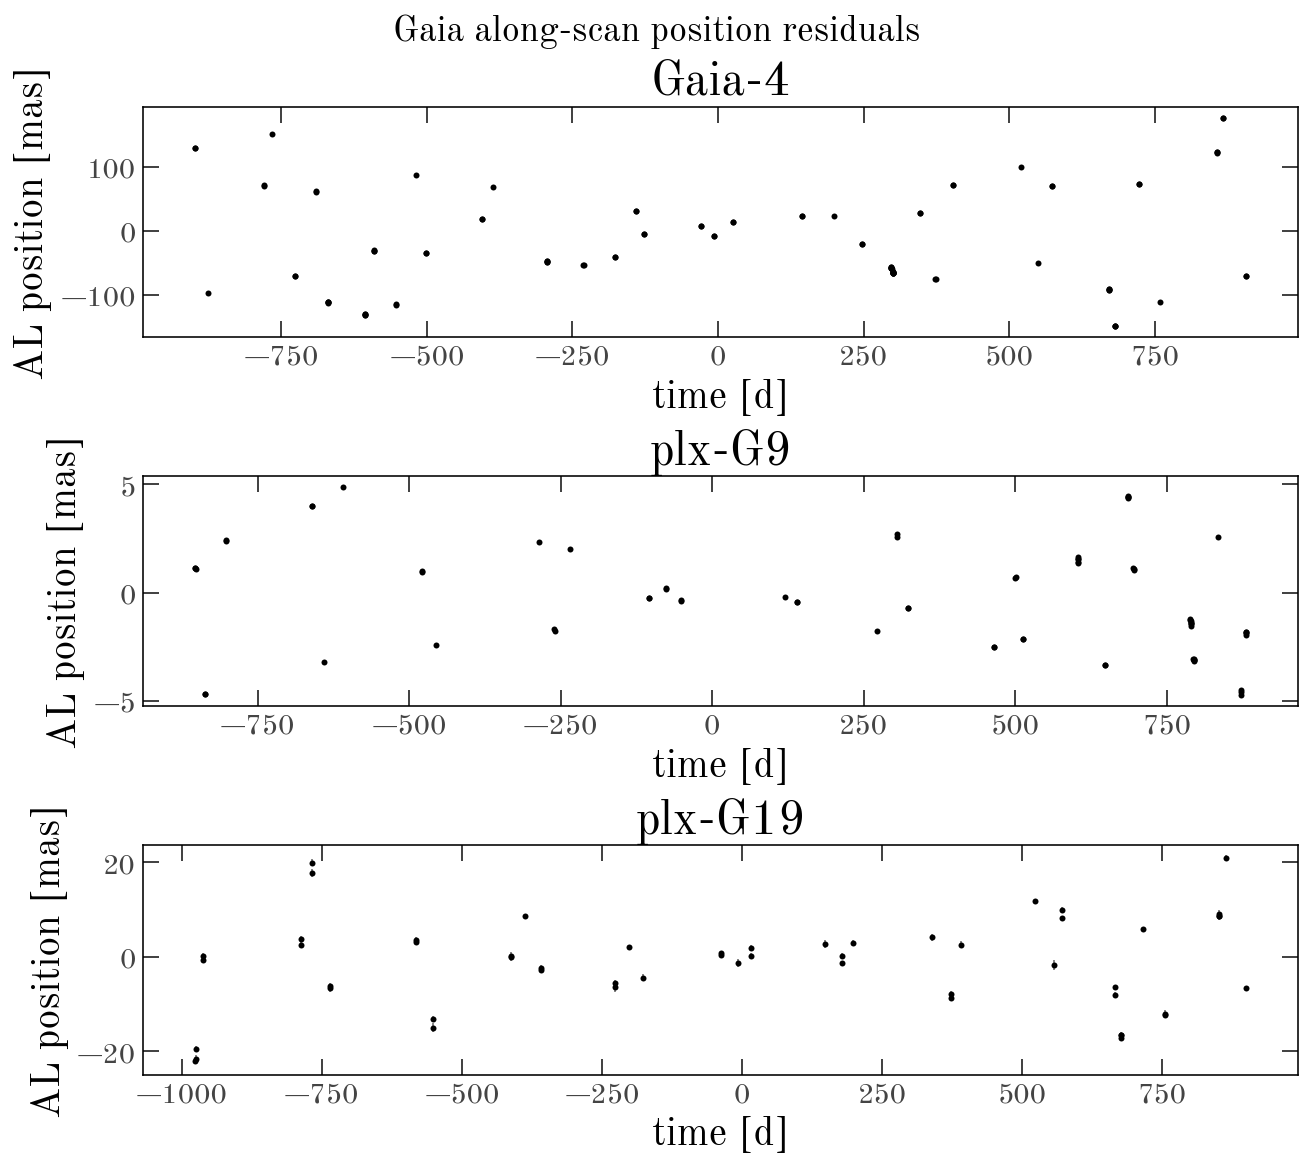

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), layout="constrained")
for ax, (name, (data, _, _)) in zip(axes, gaia_data.items(), strict=True):
    data.plot(ax=ax)
    ax.set_title(name)
_ = fig.suptitle("Gaia along-scan position residuals", fontsize=18)

The three datasets look similar in structure and the signal is mostly dominated by the parallax and linear motion of each source. But note the very different vertical scales in the three panels.

Now we have to choose the amplitude prior. Since we are searching for exoplanet-mass companions in all three systems, we can set the period-dependent prior scale from that assumption. For a companion of mass $m_2$ orbiting a star of mass $m_1$, the star's own orbit about the barycenter has semi-major axis $a_1 \approx a_\mathrm{rel} \, m_2 / m_1$. At $P_0 = 1$ year around a solar-mass star, $a_\mathrm{rel} \approx 1\,\mathrm{AU}$, so a $10\,M_\mathrm{Jup}$ companion gives $a_1 \approx 1\,\mathrm{AU} \times 10\,M_\mathrm{Jup} / M_\odot \approx 0.01\,\mathrm{AU}$. We adopt this value as the prior scale for `sigma_a0`.

One complication here that is specific to astrometry is that `sigma_a0` is a physical length, so turning it into an _angular_ prior width requires a parallax. The periodogram marginalizes over the parallax rather than sampling it, so there is no parallax value for the prior to read. In `harv`, we currently therefore have to supply a parallax measurement through `prior_params`. This only sets the prior scale and the parallax column stays in the design matrix and is still fitted and marginalized in both the trial and the base models, so passing a catalog value does not pin it to that value. 
However, it does mean that the period-dependent astrometric prior needs external information that the radial velocity case doesn't, and supplying a point measurement ignores the parallax uncertainty, which can be large for faint sources. This is something we plan to improve in the future by numerically marginalizing over the parallax in the prior, but for now this is a limitation of the implementation.

We now compute periodograms for each of the three systems. We do this with three different choices of the periodogram prior: a wide flat `sigma_amp` prior, a period-dependent `sigma_a0` prior, and the profile (maximum-likelihood) periodogram, for comparison.

First we set some scales and nuisance parameters to adopt across all of the periodograms:

In [21]:
# The primary's orbit for a 10 M_Jup companion to a solar-mass star at P0 = 1 yr.
sigma_a0 = Q.from_((1 * u.au * (10 * u.Mjup / u.Msun)).to(u.au))
print(f"sigma_a0 = {sigma_a0:.5f}")

gaia_P_min, gaia_P_max = Q(20.0, "day"), Q(4000.0, "day")
gaia_nuisance_kw = {
    "period_min": gaia_P_min,
    "period_max": gaia_P_max,
    "sigma_pos": Q(500.0, "mas"),
    "sigma_pm": Q(500.0, "mas/yr"),
    "sigma_parallax": Q(100.0, "mas"),
}

sigma_a0 = 0.00955 AU


In [ ]:
def scan_gaia(data, parallax, n_terms=1):
    """Periodograms of one system under all three amplitude-prior choices."""
    grid = hp.frequency_grid(
        data, period_min=gaia_P_min, period_max=gaia_P_max, samples_per_peak=8
    )
    flat_prior = hm.FourierGaiaAstrometry(n_terms=n_terms).default_prior(
        **gaia_nuisance_kw, sigma_amp=Q(5.0, "mas")
    )
    P_dep_prior = hm.FourierGaiaAstrometry(n_terms=n_terms).default_prior(
        **gaia_nuisance_kw, sigma_a0=sigma_a0, P0=Q(1.0, "yr")
    )
    return {
        "flat prior": hp.periodogram(data, grid, prior=flat_prior, n_terms=n_terms),
        "$P$-dependent prior": hp.periodogram(
            data,
            grid,
            prior=P_dep_prior,
            n_terms=n_terms,
            prior_params={"parallax": parallax},
        ),
        "profile periodogram": hp.periodogram(data, grid, prior=False, n_terms=n_terms),
    }


# Compute all of the periodograms:
gaia_pgrams = {
    name: scan_gaia(data, parallax) for name, (data, parallax, _) in gaia_data.items()
}

With the periodograms computed, we now visualize the different periodograms for each dataset:

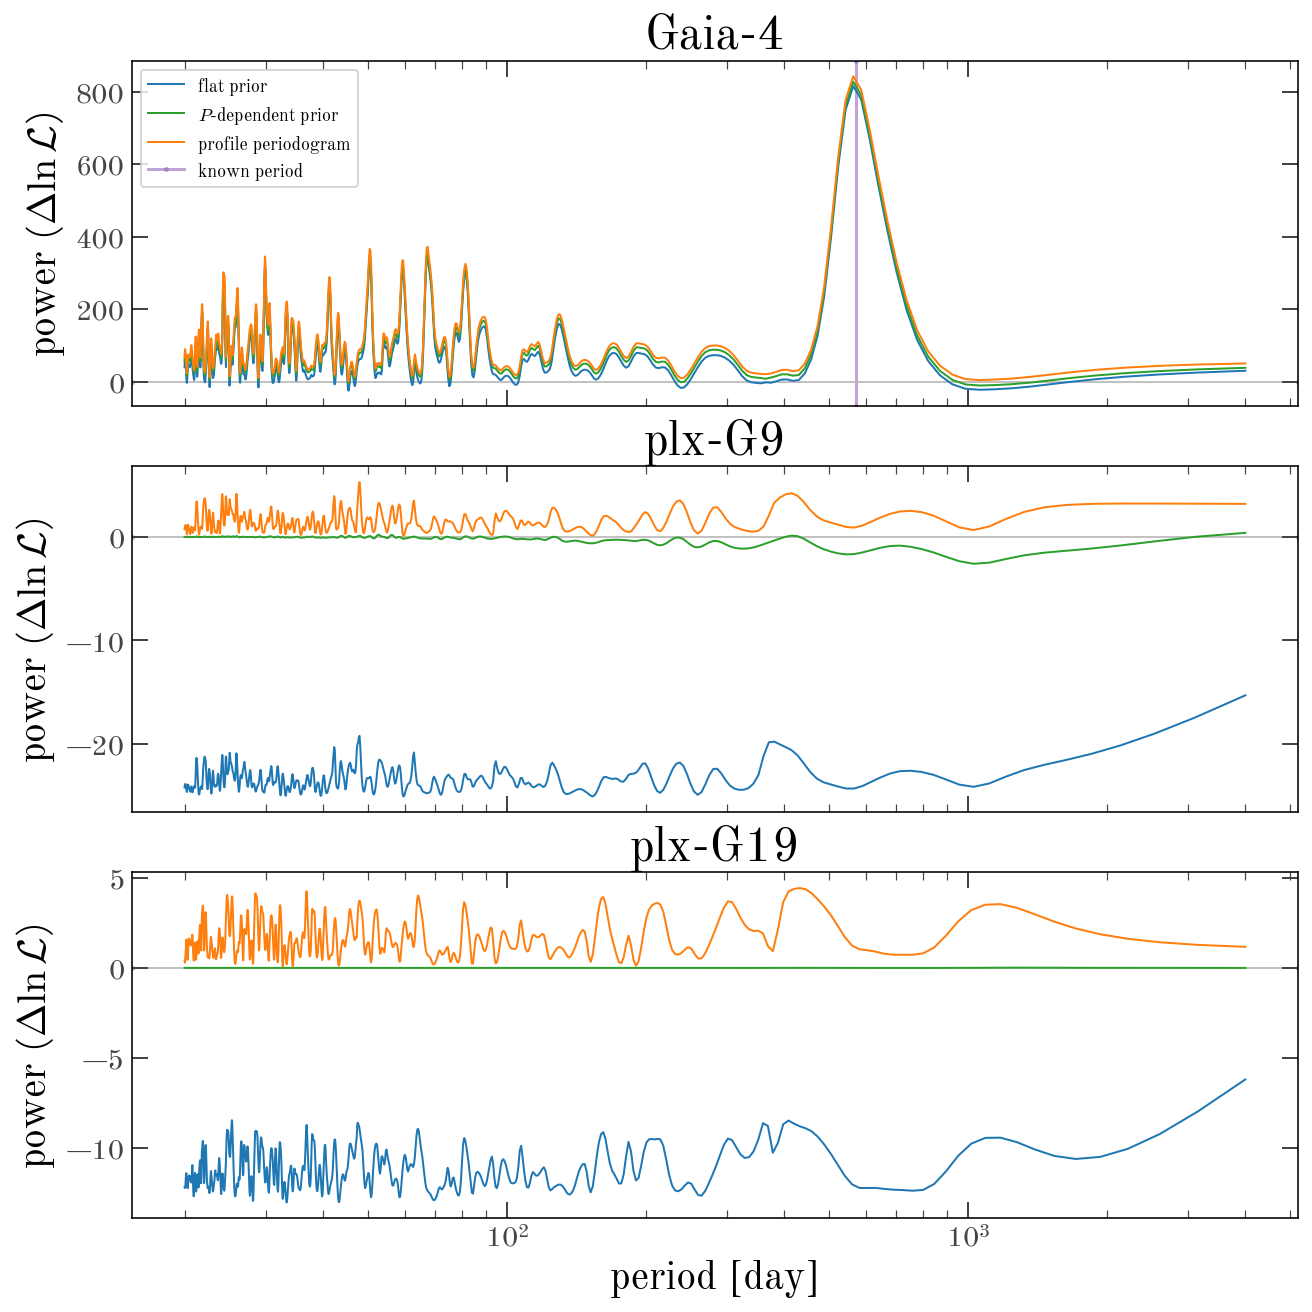

In [29]:
pgram_colors = {
    "flat prior": "tab:blue",
    "$P$-dependent prior": "tab:green",
    "profile periodogram": "tab:orange",
}

fig, axes = plt.subplots(3, 1, figsize=(9, 9), layout="constrained", sharex=True)
for ax, (name, pgrams) in zip(axes, gaia_pgrams.items(), strict=True):
    for label, res in pgrams.items():
        ax.plot(
            ustrip("day", res.period),
            res.delta_ln_likelihood,
            color=pgram_colors[label],
            lw=1,
            marker="",
            label=label,
        )
    ax.axhline(0.0, color="0.7", lw=0.8, zorder=0)

    known_period = gaia_data[name][2]
    if np.isfinite(known_period):
        ax.axvline(
            known_period,
            color="tab:purple",
            ls="-",
            lw=1.5,
            label="known period",
            zorder=-10,
            alpha=0.6,
        )

    ax.set(
        xscale="log",
        ylabel=r"power ($\Delta \ln \mathcal{L}$)",
        title=name,
    )
axes[0].legend(fontsize=9, loc="upper left")
_ = axes[-1].set_xlabel("period [day]")

Each panel is a different source (i.e. different data) from the Gaia DR4 prerelease, and each colored line is a different periodogram choice.

**Gaia-4**: All three periodograms show a clear and dominant peak at ~564 days, close to the known ~571 day period. Apart from an offset, the structure of the periodograms is nearly identical. This is the same point as we saw above in our demonstrations with radial velocity data: when the period is well determined, neither the choice of statistic (profile vs. marginalized) nor the choice of prior changes the periodogram interpretation. 

**plx-G9**: Here the flat prior (constant amplitude) periodogram (blue line) is negative at every trial period. This is because of the Occam factor, and the interpretation here is that the linear motion / standard astrometric solution model is sufficient for describing the data. Adding the additional sinusoidal terms to the design matrix don't improve things more than the cost of adding the additional free parameters. The periodogram with the period-dependent prior instead sits near zero, and dipping to negative values. This is because a $10\,M_\mathrm{Jup}$ companion at this parallax would produce a wobble of about 0.01 mas whereas the per-transit uncertainties are ~0.035 mas. So the prior is narrow enough that the orbit columns don't help or hurt relative to the standard astrometric model. The profile periodogram is again >0 at all periods with a highest peak around 48 days, but this is provably just noise. 

**plx-G19**: This is similar to the case of plx-G9 but more extreme. This star is very faint, with per-transit uncertainties around ~0.66 mas, so the expected signal of a ~10 Mjup companion is only 0.007 mas, which is 100 times below the noise level. The period-dependent periodogram is therefore almost completely flat, which says that the data are inconclusive for finding an exoplanet-mass companion at any period. The profile periodogram again shows spurious structure with several modes of comparable amplitude.

These examples demonstrate that a marginalized periodogram provide some capacity for interpretation that we can't get natively from a profile periodogram. A flat marginalized periodogram (no significant peaks as a function of period) means that the data don't have capacity to answer the question. 
A fully negative periodogram means that the trial periods are actively disfavored relative to having no companion at all. 

## Conclusions and Next steps

Where the amplitudes (linear parameters) are well constrained, the marginal and profile periodograms tell you the same thing about the period of a signal in your data. 
However, the marginalized periodogram has two benefits over the more classical profile (Lomb–Scargle) type periodogram: (1) the periodogram power provides immediate model selection interpretation as a log Bayes factor, and (2) the marginal periodogram can be used with a prior on the amplitudes (linear parameters), and that prior can depend on period in a way to build in physical knowledge about the systems you are searching for. 

In `harv`, the usual next step is to turn the periodogram into an interim period prior for the rejection sampler with {py:func}`~harv.periodogram.attach_interim_period_prior`, so that prior samples concentrate near the periods the data prefer.